In [1]:
# =========================================================
# IMPORT LIBRARIES + LOAD DEFECT DENSITY SHEET
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [3]:
# =========================================================
# LOAD DEFECT DENSITY SHEET
# =========================================================

file_path = "Data_file.xlsx"
sheet_name = "Defect Density"

# Load dataset
df = pd.read_excel(file_path, sheet_name=sheet_name)

# Display basic info
print("Defect Density Sheet Loaded Successfully!")
print("Shape of Dataset:", df.shape)

# Show column names
print("\nColumns in Defect Density Sheet:")
print(df.columns.tolist())

# Preview first rows
df.head()

Defect Density Sheet Loaded Successfully!
Shape of Dataset: (61, 32)

Columns in Defect Density Sheet:
['Jsc', 'v(V)', '10^13', '10^14', '10^15', '10^16', '10^17', '10^18', 'Unnamed: 8', 'Unnamed: 9', 'Defect Density', 'Jsc(mA/cm^2', 'Unnamed: 12', 'Unnamed: 13', 'Q.E.(%)', 'lambda(nm)', '10^13.1', '10^14.1', '10^15.1', '10^16.1', '10^17.1', '10^18.1', 'Unnamed: 22', 'Unnamed: 23', 'R(A/W)', 'lambda(nm).1', '10^13.2', '10^14.2', '10^15.2', '10^16.2', '10^17.2', '10^18.2']


,Jsc,v(V),10^13,10^14,10^15,10^16,10^17,10^18,Unnamed: 8,Unnamed: 9,...,Unnamed: 22,Unnamed: 23,R(A/W),lambda(nm).1,10^13.2,10^14.2,10^15.2,10^16.2,10^17.2,10^18.2
0,NaN,0.00,23.596469,23.592444,23.552353,23.167019,20.480213,15.695089,NaN,NaN,...,NaN,NaN,NaN,300,0.203713,0.203713,0.203705,0.203639,0.203267,0.202482
1,NaN,0.05,23.596327,23.592076,23.549746,23.143851,20.366745,15.627330,NaN,NaN,...,NaN,NaN,NaN,310,0.212987,0.212986,0.212978,0.212903,0.212472,0.211500
2,NaN,0.10,23.596181,23.591677,23.546834,23.117989,20.245009,15.558466,NaN,NaN,...,NaN,NaN,NaN,320,0.222504,0.222503,0.222494,0.222411,0.221910,0.220716
3,NaN,0.15,23.596031,23.591239,23.543555,23.088918,20.114117,15.488488,NaN,NaN,...,NaN,NaN,NaN,330,0.232310,0.232309,0.232298,0.232204,0.231621,0.230167
4,NaN,0.20,23.595875,23.590756,23.539829,23.055977,19.973056,15.417368,NaN,NaN,...,NaN,NaN,NaN,340,0.242466,0.242465,0.242453,0.242346,0.241666,0.239907


In [4]:
# =========================================================
# EXTRACT J-V DATA (DEFECT DENSITY)
# =========================================================

# Select voltage + J-V columns only
jv_cols = ['v(V)'] + [
    col for col in df.columns
    if str(col).startswith('10^') and '.1' not in str(col) and '.2' not in str(col)
]

# Create J-V dataframe
jv_df = df[jv_cols]

# Convert wide to long format
jv_long = jv_df.melt(
    id_vars='v(V)',
    var_name='Defect_Density',
    value_name='Current'
)

# Extract exponent only (10^13 → 13)
jv_long['Defect_Density'] = jv_long['Defect_Density'].str.extract(r'10\^(\d+)').astype(float)

# Remove NaN values
jv_long.dropna(inplace=True)

# Rename columns
jv_long.rename(columns={'v(V)': 'Voltage'}, inplace=True)

# Reset index
jv_long.reset_index(drop=True, inplace=True)

print("J-V Defect Density Data Ready!")
print("Shape:", jv_long.shape)

jv_long.head()

J-V Defect Density Data Ready!
Shape: (144, 3)


,Voltage,Defect_Density,Current
0,0.00,13.0,23.596469
1,0.05,13.0,23.596327
2,0.10,13.0,23.596181
3,0.15,13.0,23.596031
4,0.20,13.0,23.595875


In [5]:
# =========================================================
# EXTRACT QE DATA (DEFECT DENSITY)
# =========================================================

# Select wavelength + QE columns only
qe_cols = ['lambda(nm)'] + [
    col for col in df.columns
    if str(col).startswith('10^') and '.1' in str(col)
]

# Create QE dataframe
qe_df = df[qe_cols]

# Convert wide to long format
qe_long = qe_df.melt(
    id_vars='lambda(nm)',
    var_name='Defect_Density',
    value_name='QE'
)

# Extract exponent only (10^13.1 → 13)
qe_long['Defect_Density'] = qe_long['Defect_Density'].str.extract(r'10\^(\d+)').astype(float)

# Remove NaN values
qe_long.dropna(inplace=True)

# Rename columns
qe_long.rename(columns={'lambda(nm)': 'Wavelength'}, inplace=True)

# Reset index
qe_long.reset_index(drop=True, inplace=True)

print("QE Defect Density Data Ready!")
print("Shape:", qe_long.shape)

qe_long.head()

QE Defect Density Data Ready!
Shape: (366, 3)


,Wavelength,Defect_Density,QE
0,300,13.0,84.20150
1,310,13.0,85.19468
2,320,13.0,86.22042
3,330,13.0,87.29208
4,340,13.0,88.42871


In [6]:
# =========================================================
# EXTRACT RESPONSIVITY DATA (DEFECT DENSITY)
# =========================================================

# Select wavelength + Responsivity columns only
r_cols = ['lambda(nm).1'] + [
    col for col in df.columns
    if str(col).startswith('10^') and '.2' in str(col)
]

# Create Responsivity dataframe
r_df = df[r_cols]

# Convert wide to long format
r_long = r_df.melt(
    id_vars='lambda(nm).1',
    var_name='Defect_Density',
    value_name='Responsivity'
)

# Extract exponent only (10^13.2 → 13)
r_long['Defect_Density'] = r_long['Defect_Density'].str.extract(r'10\^(\d+)').astype(float)

# Remove NaN values
r_long.dropna(inplace=True)

# Rename columns
r_long.rename(columns={'lambda(nm).1': 'Wavelength'}, inplace=True)

# Reset index
r_long.reset_index(drop=True, inplace=True)

print("Responsivity Defect Density Data Ready!")
print("Shape:", r_long.shape)

r_long.head()

Responsivity Defect Density Data Ready!
Shape: (366, 3)


,Wavelength,Defect_Density,Responsivity
0,300,13.0,0.203713
1,310,13.0,0.212987
2,320,13.0,0.222504
3,330,13.0,0.232310
4,340,13.0,0.242466


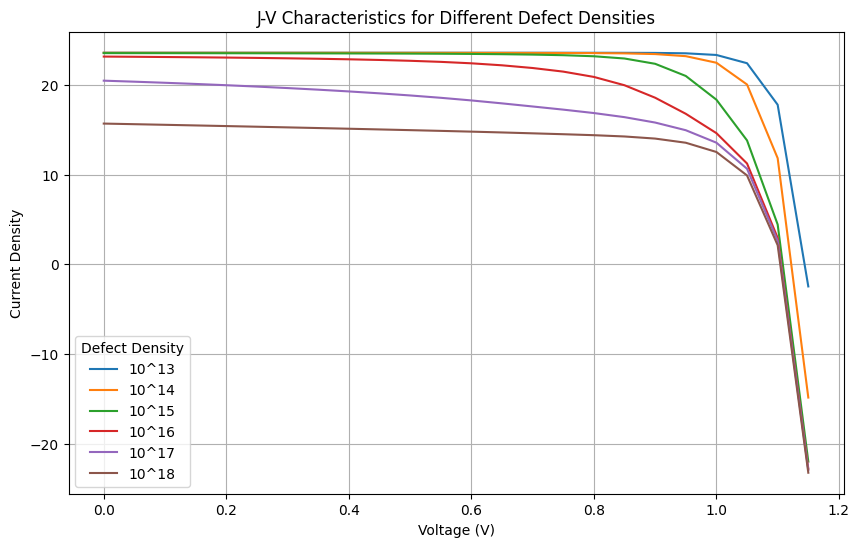

In [7]:
# =========================================================
# PLOT J-V CURVES (DEFECT DENSITY)
# =========================================================

plt.figure(figsize=(10,6))

for defect in sorted(jv_long['Defect_Density'].unique()):
    subset = jv_long[jv_long['Defect_Density'] == defect]

    plt.plot(
        subset['Voltage'],
        subset['Current'],
        label=f'10^{int(defect)}'
    )

plt.title("J-V Characteristics for Different Defect Densities")
plt.xlabel("Voltage (V)")
plt.ylabel("Current Density")

plt.legend(title="Defect Density")
plt.grid(True)
plt.show()

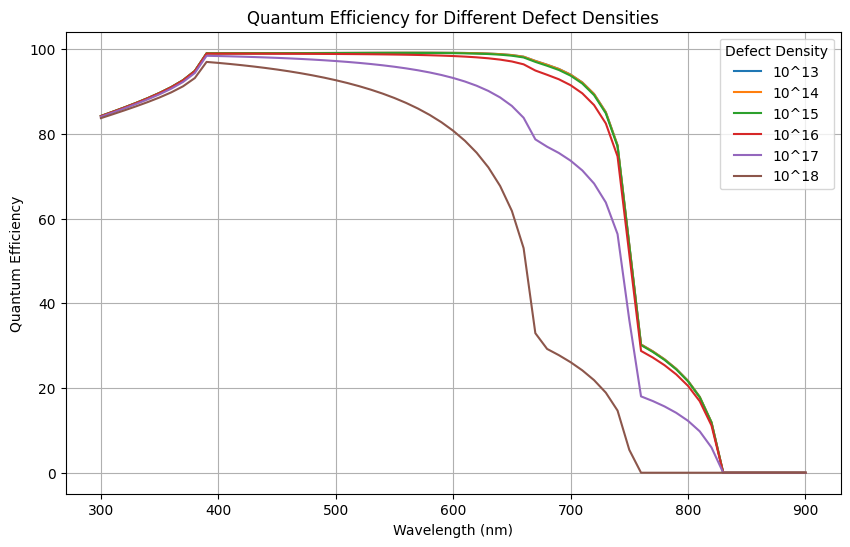

In [8]:
# =========================================================
# PLOT QE CURVES (DEFECT DENSITY)
# =========================================================

plt.figure(figsize=(10,6))

for defect in sorted(qe_long['Defect_Density'].unique()):
    subset = qe_long[qe_long['Defect_Density'] == defect]

    plt.plot(
        subset['Wavelength'],
        subset['QE'],
        label=f'10^{int(defect)}'
    )

plt.title("Quantum Efficiency for Different Defect Densities")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Quantum Efficiency")

plt.legend(title="Defect Density")
plt.grid(True)
plt.show()

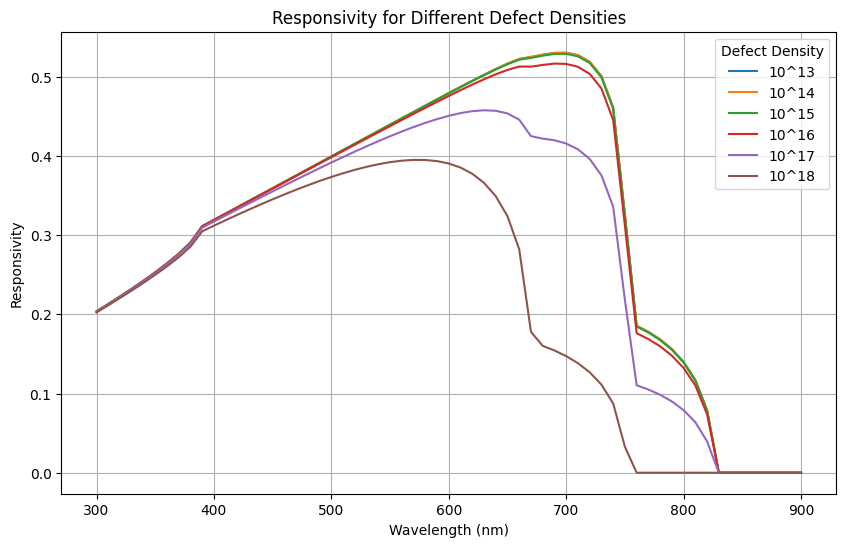

In [9]:
# =========================================================
# PLOT RESPONSIVITY CURVES (DEFECT DENSITY)
# =========================================================

plt.figure(figsize=(10,6))

for defect in sorted(r_long['Defect_Density'].unique()):
    subset = r_long[r_long['Defect_Density'] == defect]

    plt.plot(
        subset['Wavelength'],
        subset['Responsivity'],
        label=f'10^{int(defect)}'
    )

plt.title("Responsivity for Different Defect Densities")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Responsivity")

plt.legend(title="Defect Density")
plt.grid(True)
plt.show()

J-V Defect Density Model Performance
R² Score: 0.9905660126658912
MAE: 0.37877574129138014


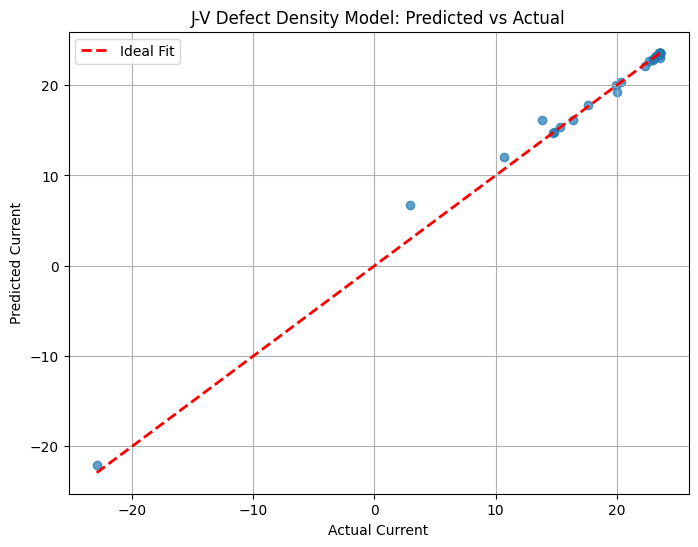

In [10]:
# =========================================================
# J-V MACHINE LEARNING MODEL (DEFECT DENSITY)
# =========================================================

# Features and target
X_jv = jv_long[['Voltage', 'Defect_Density']]
y_jv = jv_long['Current']

# Train-test split
X_train_jv, X_test_jv, y_train_jv, y_test_jv = train_test_split(
    X_jv, y_jv,
    test_size=0.2,
    random_state=42
)

# Model
jv_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
jv_model.fit(X_train_jv, y_train_jv)

# Predict
y_pred_jv = jv_model.predict(X_test_jv)

# Metrics
print("J-V Defect Density Model Performance")
print("R² Score:", r2_score(y_test_jv, y_pred_jv))
print("MAE:", mean_absolute_error(y_test_jv, y_pred_jv))

# Plot Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_jv, y_pred_jv, alpha=0.7)

# Ideal reference line
min_val = min(y_test_jv.min(), y_pred_jv.min())
max_val = max(y_test_jv.max(), y_pred_jv.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Ideal Fit"
)

plt.xlabel("Actual Current")
plt.ylabel("Predicted Current")
plt.title("J-V Defect Density Model: Predicted vs Actual")

plt.legend()
plt.grid(True)
plt.show()

QE Defect Density Model Performance
R² Score: 0.9969325944094173
MAE: 0.7655474714567315


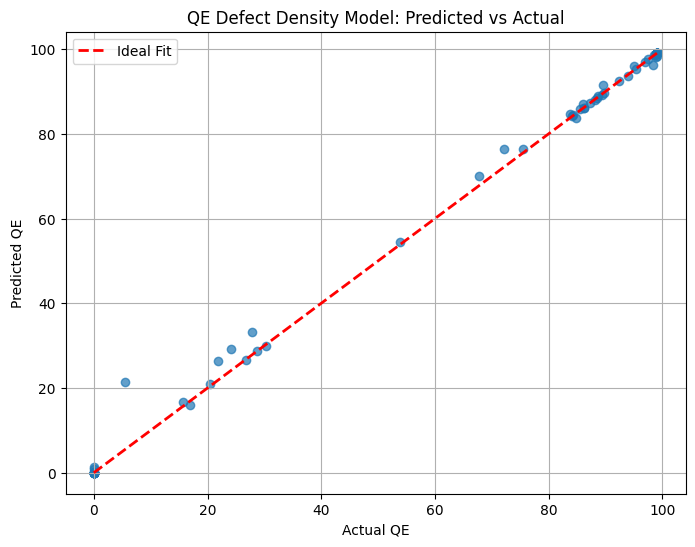

In [11]:
# =========================================================
# QE MACHINE LEARNING MODEL (DEFECT DENSITY)
# =========================================================

# Features and target
X_qe = qe_long[['Wavelength', 'Defect_Density']]
y_qe = qe_long['QE']

# Train-test split
X_train_qe, X_test_qe, y_train_qe, y_test_qe = train_test_split(
    X_qe, y_qe,
    test_size=0.2,
    random_state=42
)

# Model
qe_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
qe_model.fit(X_train_qe, y_train_qe)

# Predict
y_pred_qe = qe_model.predict(X_test_qe)

# Metrics
print("QE Defect Density Model Performance")
print("R² Score:", r2_score(y_test_qe, y_pred_qe))
print("MAE:", mean_absolute_error(y_test_qe, y_pred_qe))

# Plot Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_qe, y_pred_qe, alpha=0.7)

# Ideal reference line
min_val = min(y_test_qe.min(), y_pred_qe.min())
max_val = max(y_test_qe.max(), y_pred_qe.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Ideal Fit"
)

plt.xlabel("Actual QE")
plt.ylabel("Predicted QE")
plt.title("QE Defect Density Model: Predicted vs Actual")

plt.legend()
plt.grid(True)
plt.show()

Responsivity Defect Density Model Performance
R² Score: 0.9972864421856835
MAE: 0.0028833149131315423


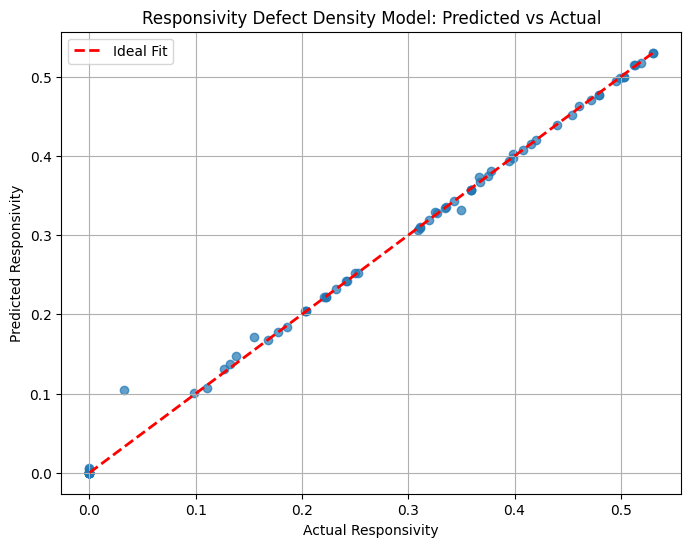

In [12]:
# =========================================================
# RESPONSIVITY MACHINE LEARNING MODEL (DEFECT DENSITY)
# =========================================================

# Features and target
X_r = r_long[['Wavelength', 'Defect_Density']]
y_r = r_long['Responsivity']

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r,
    test_size=0.2,
    random_state=42
)

# Model
r_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
r_model.fit(X_train_r, y_train_r)

# Predict
y_pred_r = r_model.predict(X_test_r)

# Metrics
print("Responsivity Defect Density Model Performance")
print("R² Score:", r2_score(y_test_r, y_pred_r))
print("MAE:", mean_absolute_error(y_test_r, y_pred_r))

# Plot Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_r, y_pred_r, alpha=0.7)

# Ideal reference line
min_val = min(y_test_r.min(), y_pred_r.min())
max_val = max(y_test_r.max(), y_pred_r.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Ideal Fit"
)

plt.xlabel("Actual Responsivity")
plt.ylabel("Predicted Responsivity")
plt.title("Responsivity Defect Density Model: Predicted vs Actual")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# =========================================================
# PREDICT CURRENT (DEFECT DENSITY)
# =========================================================

def predict_current(voltage, defect_density):

    prediction = jv_model.predict([[voltage, defect_density]])[0]

    print(f"Predicted Current Density at {voltage} V and 10^{int(defect_density)} Defect Density: {prediction}")

    return prediction

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

voltage = float(input("Enter Voltage (V): "))
defect_density = float(input("Enter Defect Density Exponent (Example: 13 for 10^13): "))

predict_current(voltage, defect_density)

In [ ]:
# =========================================================
# PREDICT QE (DEFECT DENSITY)
# =========================================================

def predict_qe(wavelength, defect_density):

    prediction = qe_model.predict([[wavelength, defect_density]])[0]

    print(f"Predicted QE at {wavelength} nm and 10^{int(defect_density)} Defect Density: {prediction}")

    return prediction

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

wavelength = float(input("Enter Wavelength (nm): "))
defect_density = float(input("Enter Defect Density Exponent (Example: 13 for 10^13): "))

predict_qe(wavelength, defect_density)

In [ ]:
# =========================================================
# PREDICT RESPONSIVITY (DEFECT DENSITY)
# =========================================================

def predict_responsivity(wavelength, defect_density):

    prediction = r_model.predict([[wavelength, defect_density]])[0]

    print(f"Predicted Responsivity at {wavelength} nm and 10^{int(defect_density)} Defect Density: {prediction}")

    return prediction

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

wavelength = float(input("Enter Wavelength (nm): "))
defect_density = float(input("Enter Defect Density Exponent (Example: 13 for 10^13): "))

predict_responsivity(wavelength, defect_density)

In [13]:
# =========================================================
# PREDICT FULL J-V CURVE (DEFECT DENSITY)
# =========================================================

def predict_jv_curve(defect_density):

    voltage_range = np.linspace(
        jv_long['Voltage'].min(),
        jv_long['Voltage'].max(),
        200
    )

    X_curve = pd.DataFrame({
        'Voltage': voltage_range,
        'Defect_Density': defect_density
    })

    predicted_current = jv_model.predict(X_curve)

    plt.figure(figsize=(10,6))

    plt.plot(
        voltage_range,
        predicted_current,
        label=f'Predicted Defect Density = 10^{int(defect_density)}'
    )

    plt.title("Predicted J-V Curve")
    plt.xlabel("Voltage (V)")
    plt.ylabel("Current Density")

    plt.legend()
    plt.grid(True)
    plt.show()

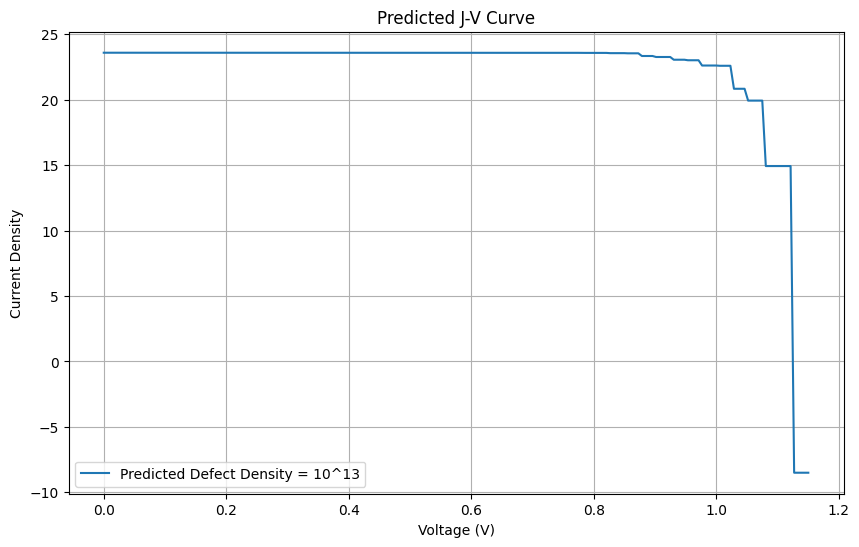

In [14]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

defect_density = float(input("Enter Defect Density Exponent (Example: 13 for 10^13): "))

predict_jv_curve(defect_density)

In [ ]:
# =========================================================
# PREDICT FULL QE CURVE (DEFECT DENSITY)
# =========================================================

def predict_qe_curve(defect_density):

    wavelength_range = np.linspace(
        qe_long['Wavelength'].min(),
        qe_long['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Defect_Density': defect_density
    })

    predicted_qe = qe_model.predict(X_curve)

    plt.figure(figsize=(10,6))

    plt.plot(
        wavelength_range,
        predicted_qe,
        label=f'Predicted Defect Density = 10^{int(defect_density)}'
    )

    plt.title("Predicted QE Curve")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Quantum Efficiency")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

defect_density = float(input("Enter Defect Density Exponent (Example: 13 for 10^13): "))

predict_qe_curve(defect_density)

In [ ]:
# =========================================================
# PREDICT FULL RESPONSIVITY CURVE (DEFECT DENSITY)
# =========================================================

def predict_r_curve(defect_density):

    wavelength_range = np.linspace(
        r_long['Wavelength'].min(),
        r_long['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Defect_Density': defect_density
    })

    predicted_r = r_model.predict(X_curve)

    plt.figure(figsize=(10,6))

    plt.plot(
        wavelength_range,
        predicted_r,
        label=f'Predicted Defect Density = 10^{int(defect_density)}'
    )

    plt.title("Predicted Responsivity Curve")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Responsivity")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

defect_density = float(input("Enter Defect Density Exponent (Example: 13 for 10^13): "))

predict_r_curve(defect_density)

In [ ]:
# =========================================================
# ACTUAL vs PREDICTED J-V CURVE (DEFECT DENSITY)
# =========================================================

def compare_jv_actual_vs_predicted(defect_density):

    # Actual SCAPS data
    actual_data = jv_long[jv_long['Defect_Density'] == defect_density]

    if actual_data.empty:
        print("Defect Density not found in dataset.")
        return

    # Predicted curve
    voltage_range = np.linspace(
        actual_data['Voltage'].min(),
        actual_data['Voltage'].max(),
        200
    )

    X_curve = pd.DataFrame({
        'Voltage': voltage_range,
        'Defect_Density': defect_density
    })

    predicted_current = jv_model.predict(X_curve)

    # Plot
    plt.figure(figsize=(10,6))

    plt.plot(
        actual_data['Voltage'],
        actual_data['Current'],
        label="Actual SCAPS"
    )

    plt.plot(
        voltage_range,
        predicted_current,
        '--',
        label="Predicted ML"
    )

    plt.title(f"Actual vs Predicted J-V Curve (10^{int(defect_density)})")
    plt.xlabel("Voltage (V)")
    plt.ylabel("Current Density")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

defect_density = float(input("Enter Existing Defect Density Exponent (Example: 13 for 10^13): "))

compare_jv_actual_vs_predicted(defect_density)

In [ ]:
# =========================================================
# ACTUAL vs PREDICTED QE CURVE (DEFECT DENSITY)
# =========================================================

def compare_qe_actual_vs_predicted(defect_density):

    # Actual SCAPS data
    actual_data = qe_long[qe_long['Defect_Density'] == defect_density]

    if actual_data.empty:
        print("Defect Density not found in dataset.")
        return

    # Predicted curve
    wavelength_range = np.linspace(
        actual_data['Wavelength'].min(),
        actual_data['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Defect_Density': defect_density
    })

    predicted_qe = qe_model.predict(X_curve)

    # Plot
    plt.figure(figsize=(10,6))

    plt.plot(
        actual_data['Wavelength'],
        actual_data['QE'],
        label="Actual SCAPS"
    )

    plt.plot(
        wavelength_range,
        predicted_qe,
        '--',
        label="Predicted ML"
    )

    plt.title(f"Actual vs Predicted QE Curve (10^{int(defect_density)})")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Quantum Efficiency")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

defect_density = float(input("Enter Existing Defect Density Exponent (Example: 13 for 10^13): "))

compare_qe_actual_vs_predicted(defect_density)

In [ ]:
# =========================================================
# ACTUAL vs PREDICTED RESPONSIVITY CURVE (DEFECT DENSITY)
# =========================================================

def compare_r_actual_vs_predicted(defect_density):

    # Actual SCAPS data
    actual_data = r_long[r_long['Defect_Density'] == defect_density]

    if actual_data.empty:
        print("Defect Density not found in dataset.")
        return

    # Predicted curve
    wavelength_range = np.linspace(
        actual_data['Wavelength'].min(),
        actual_data['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Defect_Density': defect_density
    })

    predicted_r = r_model.predict(X_curve)

    # Plot
    plt.figure(figsize=(10,6))

    plt.plot(
        actual_data['Wavelength'],
        actual_data['Responsivity'],
        label="Actual SCAPS"
    )

    plt.plot(
        wavelength_range,
        predicted_r,
        '--',
        label="Predicted ML"
    )

    plt.title(f"Actual vs Predicted Responsivity Curve (10^{int(defect_density)})")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Responsivity")

    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

defect_density = float(input("Enter Existing Defect Density Exponent (Example: 13 for 10^13): "))

compare_r_actual_vs_predicted(defect_density)

In [15]:
# =========================================================
# DEFECT DENSITY THEORY + SYSTEM WORKING
# =========================================================

print("""
============================================================
DEFECT DENSITY VARIATION THEORY IN PEROVSKITE SOLAR CELLS
============================================================

In this project, Defect Density refers to the concentration of 
electronic defect states or trap states present within a material 
layer of the solar cell, often within the absorber or transport layers.

These defects act as recombination centers that can capture charge 
carriers, reduce carrier lifetime, and degrade photovoltaic 
performance.

Thus, defect density is a critical material-quality parameter.

------------------------------------------------------------
WHY DEFECT DENSITY IS IMPORTANT
------------------------------------------------------------

Defect Density influences:
• Carrier recombination
• Trap-assisted losses
• Carrier lifetime
• Charge transport
• Current density
• Voltage behavior

At lower defect density:
• Fewer trap states
• Reduced recombination
• Better carrier survival
• Improved performance

At higher defect density:
• More trap-assisted recombination
• Increased carrier loss
• Lower extraction efficiency
• Potential performance degradation

Therefore, studying defect density helps evaluate how material 
quality impacts solar-cell operation.

------------------------------------------------------------
ROLE OF SCAPS DATASET
------------------------------------------------------------

The Excel dataset contains SCAPS-generated simulation data for 
multiple defect density values represented as:
10^13, 10^14, 10^15, 10^16, 10^17, 10^18

For each defect density, SCAPS provides:

1. J–V Data:
Voltage vs Current Density

2. QE Data:
Wavelength vs Quantum Efficiency

3. Responsivity Data:
Wavelength vs Responsivity

Each defect density therefore represents a different trap-state 
condition simulation.

------------------------------------------------------------
WHAT THIS ML SYSTEM DOES
------------------------------------------------------------

Instead of manually analyzing every defect density separately, 
Machine Learning learns defect-response behavior from SCAPS data.

Three Random Forest models are trained:

J–V Model:
(Voltage + Defect Density) → Current

QE Model:
(Wavelength + Defect Density) → QE

Responsivity Model:
(Wavelength + Defect Density) → Responsivity

For ML simplicity, densities are represented using exponent form:
10^13 → 13
10^18 → 18

This allows prediction of:
• Current at selected voltage and defect density
• QE at selected wavelength and defect density
• Responsivity at selected wavelength and defect density
• Full predicted curves for user-selected density

------------------------------------------------------------
MODEL VALIDATION
------------------------------------------------------------

To ensure reliability:
• R² Score evaluates predictive accuracy
• MAE measures average error
• Predicted vs Actual plots verify consistency

This confirms whether ML successfully captures defect-behavior trends.

------------------------------------------------------------
ACTUAL vs PREDICTED COMPARISON
------------------------------------------------------------

For known defect density values:
• Actual SCAPS curves are plotted
• Predicted ML curves are plotted

This helps evaluate:
• Learning quality
• Defect-pattern understanding
• Predictive consistency

------------------------------------------------------------
SYSTEM SIGNIFICANCE
------------------------------------------------------------

This framework combines:
SCAPS Simulation + Material Quality Analysis + Machine Learning

Thus, it serves as:
• Defect-performance analysis tool
• Predictive modeling framework
• Visualization system

Rather than replacing SCAPS, this system extends defect-density 
analysis by enabling:
• Faster predictions
• Easier material-quality exploration
• Reusable analysis framework

============================================================
FINAL SUMMARY
============================================================

Defect Density represents trap-state concentration.
It strongly affects recombination and carrier lifetime.
SCAPS provides defect-density-based simulation data.
Machine Learning learns defect-response behavior.
The final system predicts and visualizes defect density effects.

In short:
This project creates a reusable defect-density simulation and 
prediction framework for perovskite solar-cell analysis.
============================================================
""")


DEFECT DENSITY VARIATION THEORY IN PEROVSKITE SOLAR CELLS

In this project, Defect Density refers to the concentration of 
electronic defect states or trap states present within a material 
layer of the solar cell, often within the absorber or transport layers.

These defects act as recombination centers that can capture charge 
carriers, reduce carrier lifetime, and degrade photovoltaic 
performance.

Thus, defect density is a critical material-quality parameter.

------------------------------------------------------------
WHY DEFECT DENSITY IS IMPORTANT
------------------------------------------------------------

Defect Density influences:
• Carrier recombination
• Trap-assisted losses
• Carrier lifetime
• Charge transport
• Current density
• Voltage behavior

At lower defect density:
• Fewer trap states
• Reduced recombination
• Better carrier survival
• Improved performance

At higher defect density:
• More trap-assisted recombination
• Increased carrier loss
• Lower extraction 